In [8]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import logging

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from mergedownloader.downloader import Downloader
from mergedownloader.file_downloader import FileDownloader, ConnectionType, DownloadMode
from mergedownloader.inpeparser import INPE_SERVER, InpeParsers, InpeTypes
from rainreporter.reporter import Reporter
from mergedownloader.utils import DateProcessor, GISUtil

In [10]:
# Create a Downloader instance
fd = FileDownloader(
    server=INPE_SERVER,
    connection_type=ConnectionType.HTTP,
    download_mode=DownloadMode.NO_UPDATE,
)

downloader = Downloader(
    file_downloader=fd,
    local_folder="/workspaces/reports_folder/downloads",
    parsers=InpeParsers,
    log_level=logging.DEBUG,
)

Using wget through HTTP on: ftp.cptec.inpe.br


In [19]:
reporter = Reporter(
    downloader=downloader,
    config_file="/workspaces/RainReporter/reporter.json5",
    bases_folder="/workspaces/reports_folder/geobases",
)

../data/cities/cidades.shp
../data/states/BR_UF_2022.shp
../data/rivers/main_rivers.shp
../data/dams


## Daily Report

In [8]:
from rainreporter.daily_report import DailyReport

In [9]:
daily_reporter = DailyReport.from_dict(
    downloader=downloader,
    mapper=reporter.mapper,
    config={
        "nome": "Uruguai - Diario",
        "tipo": "Diario",
        "shp": "bacia_Doce.parquet",
        "total_dias": 30,
    },
    bases_folder="/workspaces/reports_folder/geobases",
)

In [ ]:
for basin in Path("/workspaces/reports_folder/geobases").glob("*.parquet"):
    print(f"Processing basin: {basin.stem}")

    daily_reporter = DailyReport.from_dict(
        downloader=downloader,
        mapper=reporter.mapper,
        config={
            "nome": basin.stem,
            "tipo": "Diario",
            "shp": basin.name,
            "total_dias": 30,
        },
        bases_folder="/workspaces/reports_folder/geobases",
    )

    # Process for various days within the current month.
    for day in range(19, 21):
        date_str = f"2026-03-{day:02d}"
        print(f"Processing date: {date_str}")

        daily_reporter.export_report_data(
            date_str,
            Path("/workspaces/reports_folder/rcar_daily_rain.parquet"),
            Path("/workspaces/reports_folder/assets"),
        )

Processing basin: Increm_Santa_Cecilia_Funil
Processing date: 2026-03-19
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Processing date: 2026-03-20
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Processing basin: UHE_Funil
Processing date: 2026-03-19
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Processing date: 2026-03-20
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Processing basin: UHE_Jaguari
Processing date: 2026-03-19
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Processing date: 2026-03-20
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Processing basin: UHE_Paraibuna
Processing date: 2026-03-19
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Coverting shp CRS to EPSG:4326
Processing date: 2

In [28]:
df = pd.read_parquet("/workspaces/reports_folder/rcar_daily_rain.parquet")
df.to_csv("/workspaces/reports_folder/rcar_daily_rain.csv", index=False)
df

,time,basin,prec,pmed,forecast
0,2026-02-20 00:00:00,bacia_Doce,2.630626,4.728848,NaN
1,2026-02-20 12:00:00,Doce,2.630626,4.728848,NaN
2,2026-02-21 00:00:00,bacia_Doce,7.914733,2.838370,NaN
3,2026-02-21 12:00:00,Doce,7.914733,2.838370,NaN
4,2026-02-22 00:00:00,bacia_Doce,8.423347,2.552218,NaN
...,...,...,...,...,...
69,2026-03-26 12:00:00,Doce,NaN,2.816830,1.404313
70,2026-03-27 00:00:00,bacia_Doce,NaN,2.103281,2.543715
71,2026-03-27 12:00:00,Doce,NaN,2.103281,2.543715
72,2026-03-28 00:00:00,bacia_Doce,NaN,2.757996,0.688011


In [33]:
df[df["basin"] == "bacia_Doce"].head(50)

,time,basin,prec,pmed,forecast
0,2026-02-20,bacia_Doce,2.630626,4.728848,NaN
2,2026-02-21,bacia_Doce,7.914733,2.838370,NaN
4,2026-02-22,bacia_Doce,8.423347,2.552218,NaN
6,2026-02-23,bacia_Doce,12.227496,3.546606,NaN
8,2026-02-24,bacia_Doce,14.324191,2.055341,NaN
10,2026-02-25,bacia_Doce,9.506857,2.838269,NaN
12,2026-02-26,bacia_Doce,19.696905,3.584964,NaN
14,2026-02-27,bacia_Doce,29.434774,3.710969,NaN
16,2026-02-28,bacia_Doce,4.172380,4.958153,NaN
18,2026-03-01,bacia_Doce,0.263010,3.249730,NaN


## Export Report Data from Reporter

In [27]:
report_kwargs={
    "nome": "bacia_Doce",
    "tipo": "Diario",
    "shp": "bacia_Doce.parquet",
    "total_dias": 30,
}

results = reporter.export_report_data(
    date_str="2026-03-23", 
    attrs=report_kwargs,
    output_db="/workspaces/reports_folder/rcar_daily_rain.parquet", 
    assets_folder="/workspaces/reports_folder/assets",
)

In [21]:
parquet = pd.read_parquet("/workspaces/reports_folder/rcar_daily_rain.parquet")

In [23]:
parquet["time"].dt.date

0     2026-02-20
1     2026-02-21
2     2026-02-22
3     2026-02-23
4     2026-02-24
5     2026-02-25
6     2026-02-26
7     2026-02-27
8     2026-02-28
9     2026-03-01
10    2026-03-02
11    2026-03-03
12    2026-03-04
13    2026-03-05
14    2026-03-06
15    2026-03-07
16    2026-03-08
17    2026-03-09
18    2026-03-10
19    2026-03-11
20    2026-03-12
21    2026-03-13
22    2026-03-14
23    2026-03-15
24    2026-03-16
25    2026-03-17
26    2026-03-18
27    2026-03-19
28    2026-03-20
29    2026-03-21
30    2026-03-22
31    2026-03-23
32    2026-03-24
33    2026-03-25
34    2026-03-26
35    2026-03-27
36    2026-03-28
Name: time, dtype: object

/usr/local/lib/python3.10/dist-packages/ecmwflibs/__init__.py:81: UserWarning: libglib-2.0.so.0: cannot open shared object file: No such file or directory
  warnings.warn(str(e))


AttributeError: type object 'Downloader' has no attribute 'get_time_series'

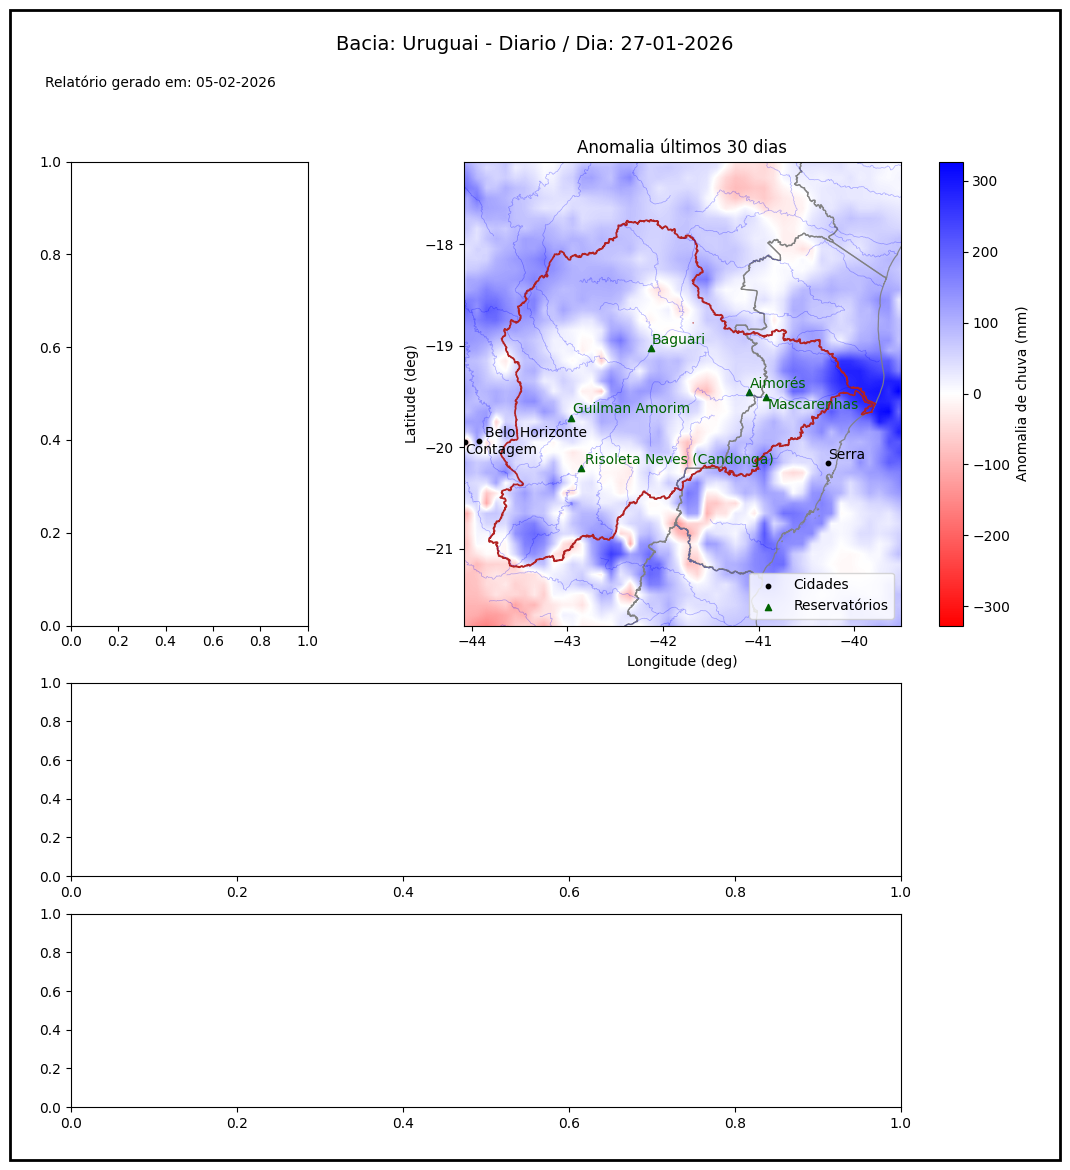

In [18]:
report = daily_reporter.generate_report("2026-01-27")

## Comparing MLTs

In [ ]:
old_mlt_path = "/workspaces/reports_folder/downloads2/MONTHLY_ACCUMULATED"
new_mlt_path = "/workspaces/reports_folder/downloads/MONTHLY_ACCUMULATED"
month = "feb"
filename = f"MERGE_CPTEC_acum_{month}.nc"

In [18]:
import xarray as xr

In [19]:
old_mlt = xr.open_dataset(f"{old_mlt_path}/{filename}")
new_mlt = xr.open_dataset(f"{new_mlt_path}/{filename}")

In [28]:
old_mlt["precacum"].mean().data, new_mlt["precacum"].mean().data

(array(116.87978213), array(101.23465854))

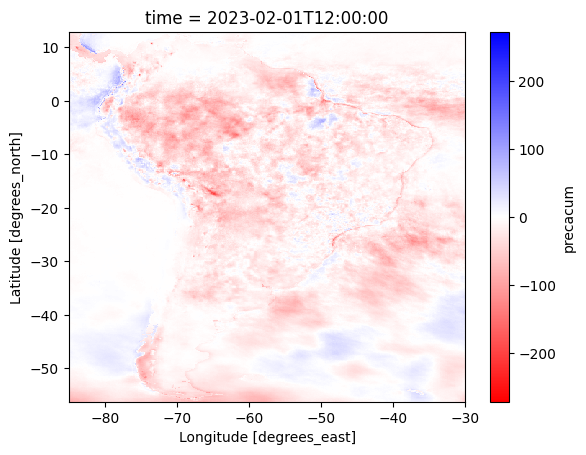

In [39]:
(new_mlt["precacum"] - old_mlt["precacum"]).plot(cmap="bwr_r")

In [35]:
import matplotlib.pyplot as plt

In [32]:
%matplotlib inline

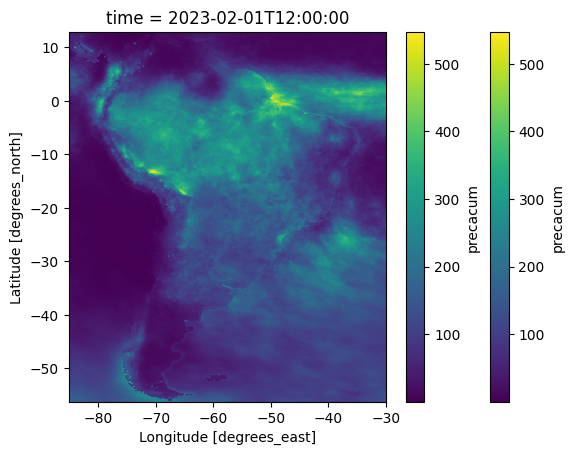

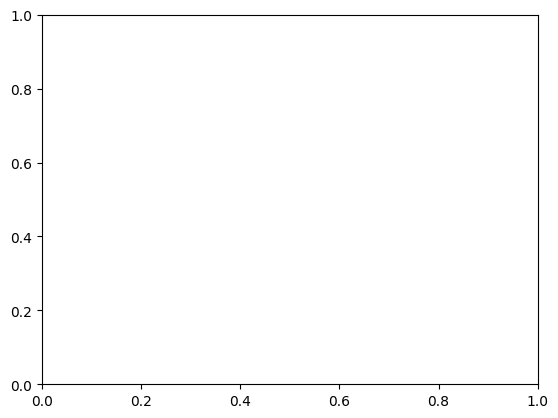

In [36]:
fig, ax = plt.subplots()